<a href="https://colab.research.google.com/github/RamadaniOktavia/2311533002_OktaviaRamadani_ImageProcessing/blob/main/Pertemuan%205/Tugas_Pertemuan_5_Image_Processing_2311533002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Membaca Gambar Asli

In [22]:
from PIL import Image

# Tentukan nama file gambar input kamu
image_path = 'IPimage.jpg'

# Membuka gambar dan memastikan formatnya RGB
img = Image.open(image_path).convert('RGB')
width, height = img.size

print(f"Gambar asli berhasil dimuat! Ukuran: {width} x {height} piksel.")

Gambar asli berhasil dimuat! Ukuran: 1080 x 720 piksel.


Blok ini bertugas membaca gambar dari komputermu dan mengambil informasi lebar (width) serta tinggi (height) gambarnya. Kita memastikan formatnya RGB agar setiap warnanya (Merah, Hijau, Biru) bisa dihitung nanti.

# 2. Membuat Zero Padding (Bingkai Hitam)

In [23]:
# Menentukan ukuran offset untuk kernel 5x5
# Kernel 5x5 butuh 2 piksel tambahan di setiap sisi (kiri, kanan, atas, bawah)
offset = 2

# Menghitung ukuran kanvas baru yang lebih besar
padded_width = width + (2 * offset)
padded_height = height + (2 * offset)

# Membuat kanvas hitam kosong dengan ukuran yang sudah diperbesar
padded_img = Image.new('RGB', (padded_width, padded_height), (0, 0, 0))

# Menempelkan gambar asli tepat di tengah-tengah kanvas hitam
padded_img.paste(img, (offset, offset))

# Memuat data piksel dari gambar yang sudah diberi bingkai padding
padded_pixels = padded_img.load()

print("Zero Padding berhasil dibuat!")
# Jika di Colab, kamu bisa mengetik 'display(padded_img)' untuk melihat gambar berbingkai hitamnya.

Zero Padding berhasil dibuat!


Karena kita memakai kernel 5x5, kita butuh ruang ekstra sebesar 2 piksel di pinggir gambar agar saat kernel menelusuri ujung gambar, ia tidak keluar jalur (error). Kita menyiasatinya dengan membuat kanvas hitam sedikit lebih besar, lalu menempelkan gambar asli di tengahnya.

# 3. Menyiapkan Kanvas Output dan Parameter Kernel

In [24]:
# Membuat kanvas kosong untuk hasil akhir (ukurannya kembali normal seperti gambar asli)
result_img = Image.new('RGB', (width, height))
result_pixels = result_img.load()

# Menentukan bobot untuk Kernel Mean Filter 5x5
# Karena ada 25 kotak (5x5) yang semuanya bernilai 1, maka rata-ratanya adalah dibagi 25
weight = 1 / 25.0

print("Kanvas hasil dan parameter kernel siap.")

Kanvas hasil dan parameter kernel siap.


Kita butuh kanvas kosong baru dengan ukuran asli untuk menggambar hasil akhirnya nanti. Angka 1 / 25.0 adalah rumus wajib untuk mean filter 5x5 (yaitu membagi total jumlah dari 25 piksel tetangga).

# 4. Proses Konvolusi (Inti Program)

In [25]:
# Looping menyusuri setiap koordinat piksel pada gambar asli
for y in range(height):
    for x in range(width):

        # Variabel untuk menampung jumlah warna di area 5x5
        sum_r, sum_g, sum_b = 0, 0, 0

        # Looping untuk area kernel 5x5 di sekitar titik (x,y)
        for ky in range(-offset, offset + 1):
            for kx in range(-offset, offset + 1):
                # Membaca warna RGB dari citra yang SUDAH di-padding
                r, g, b = padded_pixels[x + offset + kx, y + offset + ky]

                # Menambahkan nilainya
                sum_r += r
                sum_g += g
                sum_b += b

        # Mengalikan total jumlah dengan bobot (1/25) dan membulatkannya jadi integer
        new_r = int(sum_r * weight)
        new_g = int(sum_g * weight)
        new_b = int(sum_b * weight)

        # Mewarnai kanvas hasil dengan piksel yang baru
        result_pixels[x, y] = (new_r, new_g, new_b)

print("Proses konvolusi selesai dilakukan!")

Proses konvolusi selesai dilakukan!


Di sini program mengecek setiap piksel satu per satu. Di tiap piksel, program akan melihat 25 piksel tetangganya (area 5x5), mengambil nilai warnanya, menjumlahkannya, lalu membaginya dengan 25. Hasil rata-rata warna itulah yang menjadi warna baru di gambar akhir (blur). Kita mengambil warnanya dari padded_pixels agar ujung gambar tidak error.

# 5. Menyimpan dan Menampilkan Hasil

Gambar berhasil disimpan sebagai: output_mean_padded.jpg


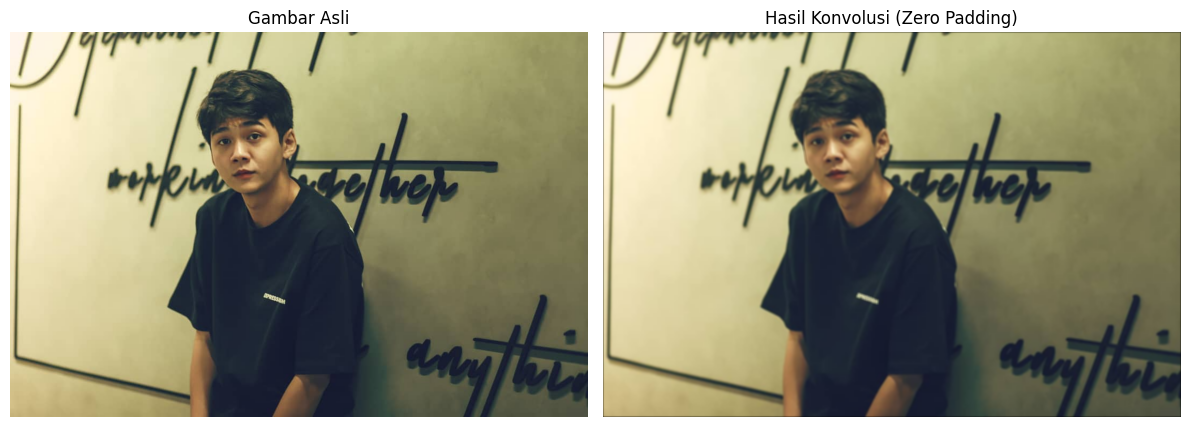

In [26]:
# Menentukan nama file output
output_path = 'output_mean_padded.jpg'

# Menyimpan gambar
result_img.save(output_path)
print(f"Gambar berhasil disimpan sebagai: {output_path}")

# --- Menampilkan Gambar ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
axes[0].set_title('Gambar Asli')
axes[0].axis('off')

axes[1].imshow(result_img)
axes[1].set_title('Hasil Konvolusi (Zero Padding)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Menyimpan gambar baru yang sudah diberi efek blur konvolusi ke dalam file output_mean_padded.jpg. Jika dijalankan di Colab/Jupyter, ini juga akan langsung menampilkan perbandingan gambar asli dan gambar hasilnya agar mudah kamu screenshot untuk laporan.